# IMDB Sentiment Analysis with a Recurrent Neural Network (RNN)

This notebook builds, trains, and evaluates a Recurrent Neural Network (using `SimpleRNN`) in TensorFlow/Keras to classify movie reviews from the IMDB dataset as **positive** or **negative**.

**Contents**
1. Setup & imports
2. Load and explore the IMDB dataset
3. Preprocess the data (padding sequences)
4. Build the RNN model
5. Train the model
6. Evaluate on the test set
7. Plot training curves
8. Test the model on custom review text


## 1. Setup & Imports

In [57]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

# For reproducibility
np.random.seed(42)
tf.random.set_seed(42)


TensorFlow version: 2.20.0


## 2. Load and Explore the IMDB Dataset

Keras ships with a preprocessed version of the IMDB dataset where reviews are already
converted to sequences of integers (each integer represents a word's rank in the overall
frequency of words in the dataset). We restrict the vocabulary to the top `NUM_WORDS`
most frequent words for efficiency.

In [58]:
NUM_WORDS = 10000  # only consider the top 10,000 most frequent words

(x_train_raw, y_train), (x_test_raw, y_test) = imdb.load_data(num_words=NUM_WORDS)

print(f"Training samples: {len(x_train_raw)}")
print(f"Testing samples:  {len(x_test_raw)}")
print(f"Example review (as integers): {x_train_raw[0][:20]}...")
print(f"Label (0=negative, 1=positive): {y_train[0]}")


Training samples: 25000
Testing samples:  25000
Example review (as integers): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]...
Label (0=negative, 1=positive): 1


In [59]:
# Let's decode a review back into readable text to see what we're working with
word_index = imdb.get_word_index()
# The first indices are reserved
reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decode_review(encoded_review):
    return " ".join(reverse_word_index.get(i, "?") for i in encoded_review)

print("Decoded example review:\n")
print(decode_review(x_train_raw[0]))
print("\nSentiment:", "Positive" if y_train[0] == 1 else "Negative")


Decoded example review:

<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and 

Average review length: 238.7 words
Median review length:  178.0 words
Max review length:     2494 words


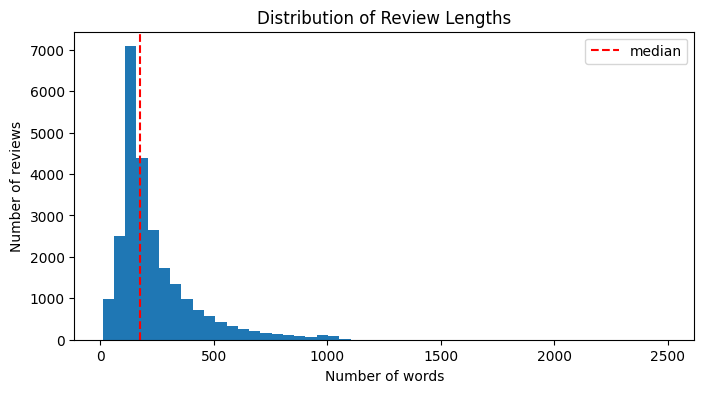

In [60]:
# Check the distribution of review lengths to help choose a padding length
review_lengths = [len(r) for r in x_train_raw]
print(f"Average review length: {np.mean(review_lengths):.1f} words")
print(f"Median review length:  {np.median(review_lengths):.1f} words")
print(f"Max review length:     {np.max(review_lengths)} words")

plt.figure(figsize=(8, 4))
plt.hist(review_lengths, bins=50)
plt.axvline(np.median(review_lengths), color="red", linestyle="--", label="median")
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of words")
plt.ylabel("Number of reviews")
plt.legend()
plt.show()


## 3. Preprocess the Data

RNNs need fixed-length input sequences within a batch, so we pad (or truncate) every
review to the same length, `MAX_LEN`. Shorter reviews are padded with zeros at the
beginning, and longer reviews are truncated.

In [61]:
MAX_LEN = 200  # each review will be truncated/padded to this many words

x_train = pad_sequences(x_train_raw, maxlen=MAX_LEN)
x_test = pad_sequences(x_test_raw, maxlen=MAX_LEN)

print("x_train shape:", x_train.shape)
print("x_test shape: ", x_test.shape)


x_train shape: (25000, 200)
x_test shape:  (25000, 200)


## 4. Build the RNN Model

Architecture:
- **Embedding layer**: maps each word index to a dense vector representation.
- **SimpleRNN layer**: processes the sequence of word embeddings, capturing sequential/context information.
- **Dense output layer**: a single neuron with sigmoid activation for binary classification (positive/negative).


In [62]:
EMBEDDING_DIM = 32
RNN_UNITS = 64

model = keras.Sequential([
    layers.Embedding(input_dim=NUM_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    layers.SimpleRNN(RNN_UNITS, dropout=0.2, recurrent_dropout=0.2),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 5. Train the Model

We hold out 20% of the training data as a validation set to monitor for overfitting,
and use early stopping to halt training once validation loss stops improving.

In [63]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

EPOCHS = 10
BATCH_SIZE = 128

history = model.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.5085 - loss: 0.7078 - val_accuracy: 0.5140 - val_loss: 0.6894
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.5365 - loss: 0.6908 - val_accuracy: 0.5688 - val_loss: 0.6825
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5439 - loss: 0.6854 - val_accuracy: 0.5748 - val_loss: 0.6793
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5691 - loss: 0.6762 - val_accuracy: 0.5784 - val_loss: 0.6698
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6093 - loss: 0.6532 - val_accuracy: 0.5716 - val_loss: 0.6588
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6372 - loss: 0.6307 - val_accuracy: 0.6094 - val_loss: 0.6447
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.6593 - loss: 0.6109 - val_accuracy: 0.6028 - val_loss: 0.6369
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6797 - loss: 0.5868 - val_accu

## 6. Evaluate on the Test Set

In [64]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")


Test loss:     0.6303
Test accuracy: 0.6298


## 7. Plot Training Curves

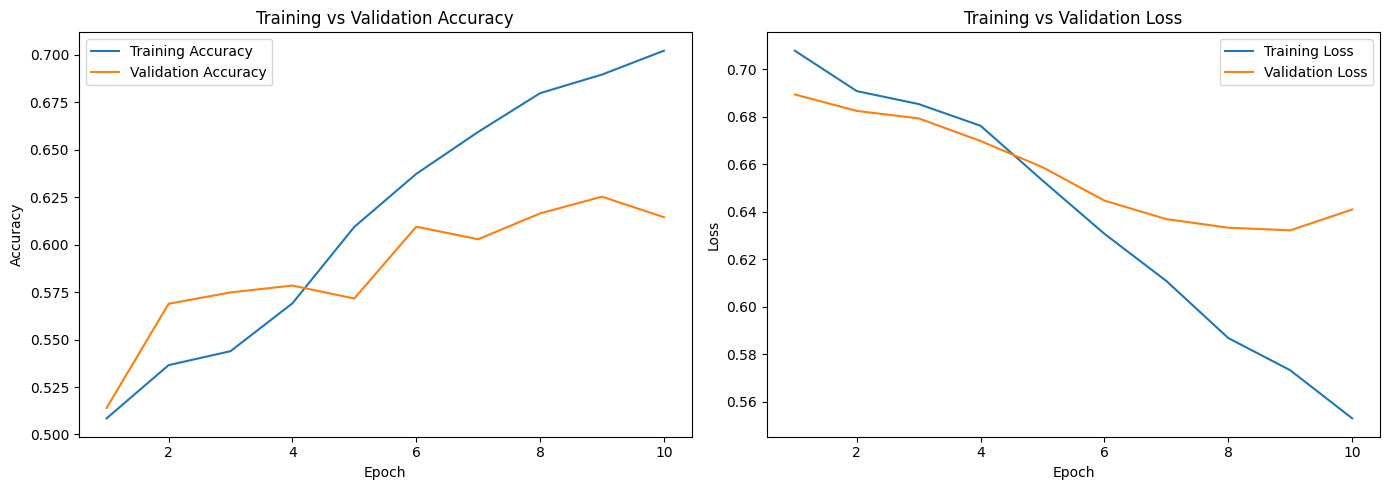

In [65]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, acc, label="Training Accuracy")
axes[0].plot(epochs_range, val_acc, label="Validation Accuracy")
axes[0].set_title("Training vs Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(epochs_range, loss, label="Training Loss")
axes[1].plot(epochs_range, val_loss, label="Validation Loss")
axes[1].set_title("Training vs Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()


## 8. Test the Model on Custom Review Text

Let's write a helper function that takes raw text, encodes it the same way the IMDB
dataset was encoded, and runs it through the trained model.

In [66]:
def encode_text(text, word_index=word_index, num_words=NUM_WORDS, max_len=MAX_LEN):
    words = text.lower().split()
    # +3 offset matches the reserved indices used by keras.datasets.imdb
    encoded = [1]  # <START> token
    for word in words:
        idx = word_index.get(word, 2) + 3  # 2 is <UNK>
        if idx < num_words:
            encoded.append(idx)
        else:
            encoded.append(2)  # <UNK>
    return pad_sequences([encoded], maxlen=max_len)

def predict_sentiment(text, model=model):
    encoded = encode_text(text)
    prob = model.predict(encoded, verbose=0)[0][0]
    sentiment = "Positive" if prob >= 0.5 else "Negative"
    return sentiment, prob

sample_reviews = [
    "This movie was absolutely wonderful, the acting was superb and I loved every minute of it",
    "This was a terrible waste of time, boring plot and awful acting",
    "Could've been better, but had a promising premise.",
]

for review in sample_reviews:
    sentiment, prob = predict_sentiment(review)
    print(f"Review: {review}")
    print(f"Predicted sentiment: {sentiment} (confidence: {prob:.4f})\n")


Review: This movie was absolutely wonderful, the acting was superb and I loved every minute of it
Predicted sentiment: Negative (confidence: 0.4754)

Review: This was a terrible waste of time, boring plot and awful acting
Predicted sentiment: Negative (confidence: 0.3269)

Review: Could've been better, but had a promising premise.
Predicted sentiment: Negative (confidence: 0.4684)

